**1. Data Collection**

In [3]:
import pandas as pd

users = pd.read_csv("Users.csv")
courses = pd.read_csv("Courses.csv")
transactions = pd.read_csv("Transactions.csv")

**2. Data Understanding**

In [4]:
users.head()
users.info()
users.describe()
users.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB


,0
UserID,0
UserName,0
Age,0
Gender,0
Email,0


**3. Data Cleaning**

In [5]:
#Missing Values
users.isnull().sum()
users.duplicated().sum()
users.dtypes

,0
UserID,object
UserName,object
Age,int64
Gender,object
Email,object


**Step 4: Merge the Tables**

This is the most important step.
As mentioned in methodology:

**Join Users + Transactions + Courses**

In [6]:
#First Merge

merged = pd.merge(
    transactions,
    users,
    on='UserID'
)

#Second Merge

final_df = pd.merge(
    merged,
    courses,
    on='CourseID'
)

**Step 5: Create Age Groups**

Requirement says:

<18

18-25

26-35

36-45

45+

In [7]:
#Create age bands.

bins = [0,18,25,35,45,100]

labels = [
    '<18',
    '18-25',
    '26-35',
    '36-45',
    '45+'
]

final_df['AgeGroup'] = pd.cut(
    final_df['Age'],
    bins=bins,
    labels=labels
)

**Step 6: Solve Analytical Questions**

**Question 1- What is the age distribution of learners on EduPro?**

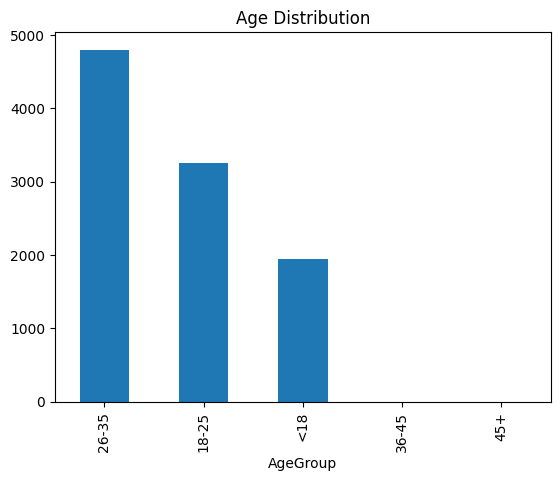

In [8]:
import matplotlib.pyplot as plt

final_df['AgeGroup'].value_counts().plot(
    kind='bar'
)

plt.title("Age Distribution")
plt.show()

Insight of above question is:

Most learners belong to the 26–35 age group.
Learners below 18 are the smallest segment. **bold text**

**Question 2- How does course enrollment vary across age groups?**

/tmp/ipykernel_2513/3760106919.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_df.groupby(


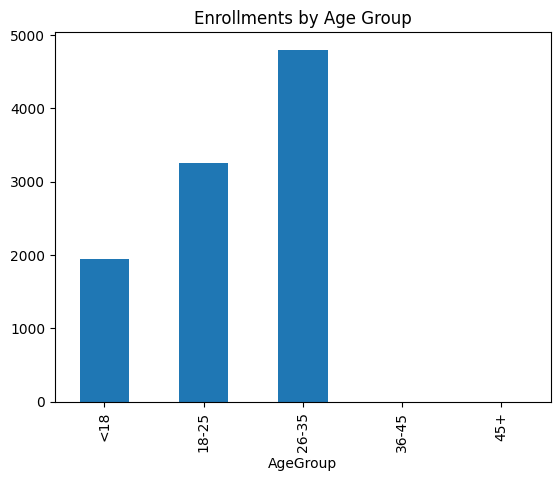

In [9]:
final_df.groupby(
    'AgeGroup'
).size().plot(
    kind='bar'
)

plt.title("Enrollments by Age Group")
plt.show()

Insight:

26–35 age group has the highest enrollments.
Enrollment decreases in older age groups. **bold text**

**Question 3- Are there gender-based differences in course selection?**

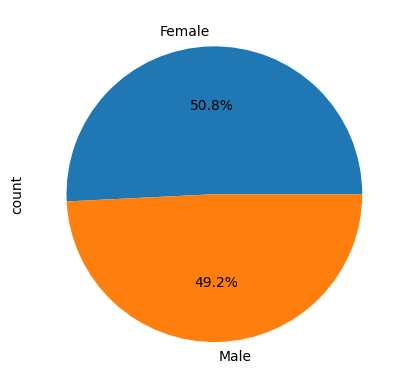

In [10]:
final_df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

Insight:

Male and Female participation is almost balanced.
Female learners show strong engagement in online courses. **bold text**

**Question 4-  Which course categories attract the highest enrollments?**

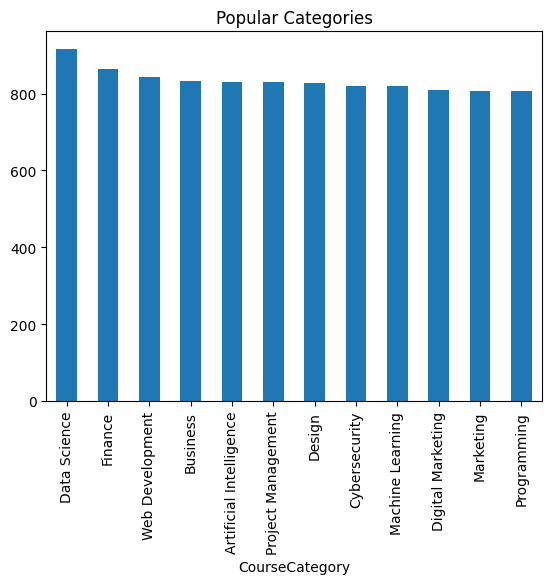

In [11]:
final_df['CourseCategory'].value_counts().plot(
    kind='bar'
)

plt.title("Popular Categories")
plt.show()

Insight:

Technology courses receive the highest enrollments.
Business and Marketing follow closely. **bold text**

**Question 5- Do beginners prefer certain course types or levels?**

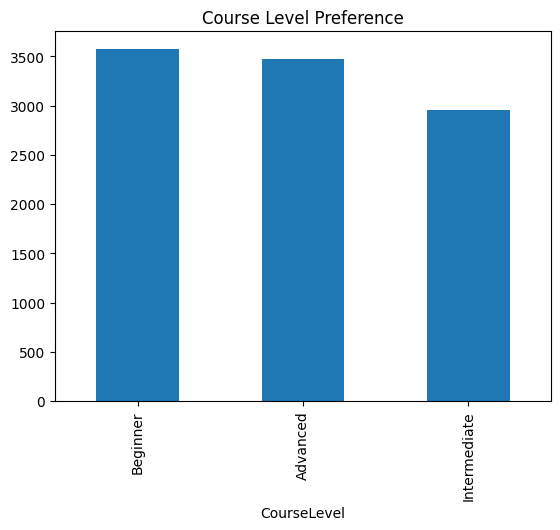

In [12]:
final_df['CourseLevel'].value_counts().plot(
    kind='bar'
)

plt.title("Course Level Preference")
plt.show()

**Question 6- Are there gender-based differences in course selection?**

<Axes: xlabel='CourseLevel', ylabel='Gender'>

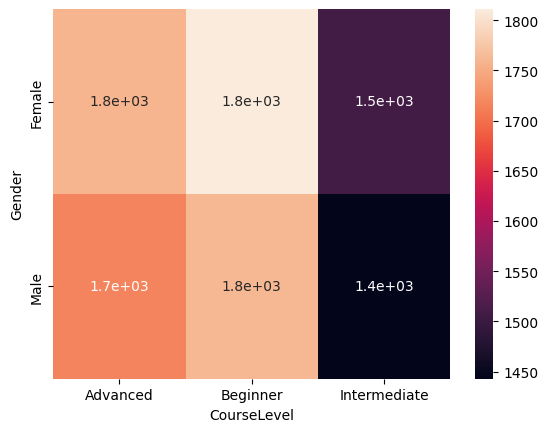

In [13]:
import seaborn as sns

pivot = pd.crosstab(
    final_df['Gender'],
    final_df['CourseLevel']
)

sns.heatmap(
    pivot,
    annot=True
)

**Question 7- Which course categories are preferred by different learner segments?**

<Axes: xlabel='CourseCategory', ylabel='AgeGroup'>

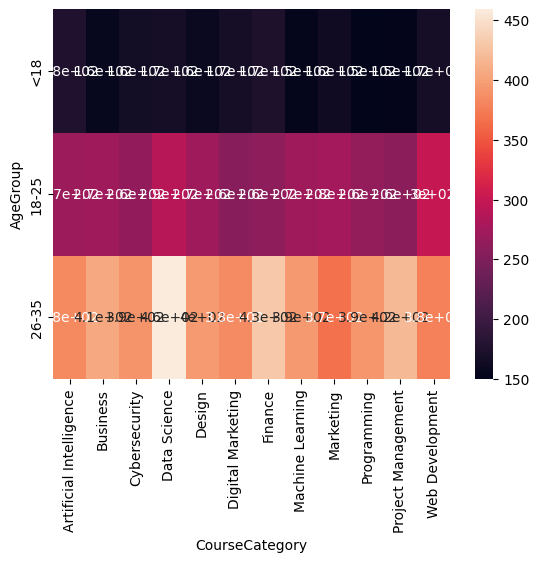

In [14]:
pivot = pd.crosstab(
    final_df['AgeGroup'],
    final_df['CourseCategory']
)

sns.heatmap(
    pivot,
    annot=True
)

**Question 8- Are beginner, intermediate, or advanced courses more popular among specific age groups?**

<Axes: xlabel='CourseLevel', ylabel='AgeGroup'>

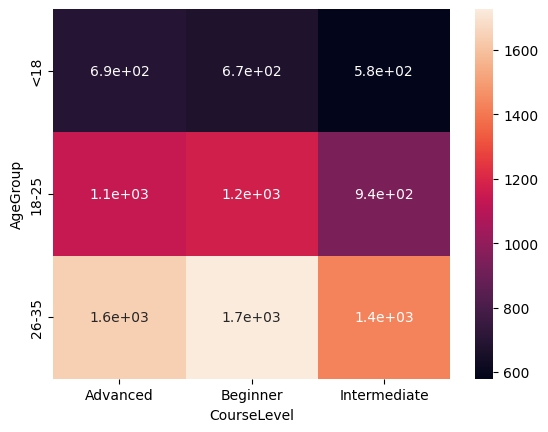

In [15]:
pivot = pd.crosstab(
    final_df['AgeGroup'],
    final_df['CourseLevel']
)

sns.heatmap(
    pivot,
    annot=True
)

**Step 7: KPI Calculations**

In [16]:
# Total Learners
total_learners = final_df['UserID'].nunique()

# Total Courses
total_courses = final_df['CourseID'].nunique()

# Total Enrollments
total_enrollments = len(final_df)

# Most Popular Category
popular_category = final_df['CourseCategory'].mode()[0]

# Most Popular Level
popular_level = final_df['CourseLevel'].mode()[0]

print(total_learners)
print(total_courses)
print(total_enrollments)
print(popular_category)
print(popular_level)

3000
60
10000
Data Science
Beginner


In [19]:
final_df.to_csv("EduPro_Final.csv", index=False)